In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

In [2]:
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("Unique labels:", set(y))

Shape of X: (70000, 784)
Shape of y: (70000,)
Unique labels: {'6', '3', '0', '1', '4', '9', '7', '2', '8', '5'}


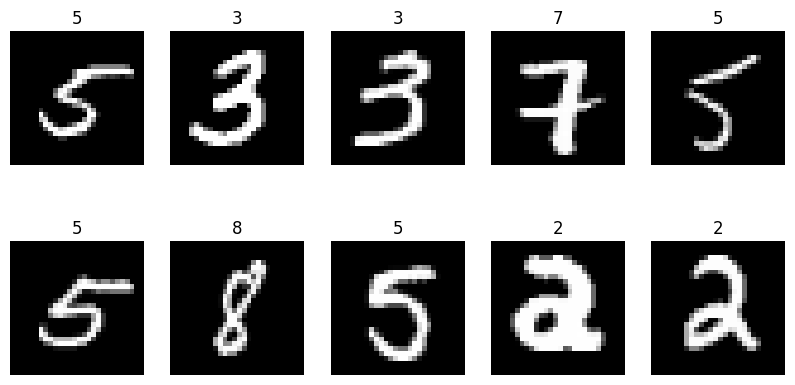

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10,5))

for ax in axes.flat:
    
    idx = np.random.randint(0, X.shape[0])
    
    image = X[idx].reshape(28,28)
    
    ax.imshow(image, cmap='gray')
    ax.set_title(y[idx])
    ax.axis('off')

plt.show()

In [4]:
pca_2 = PCA(n_components=2)

X_pca_2d = pca_2.fit_transform(X)

print("Original shape:", X.shape)
print("Reduced shape:", X_pca_2d.shape)

Original shape: (70000, 784)
Reduced shape: (70000, 2)


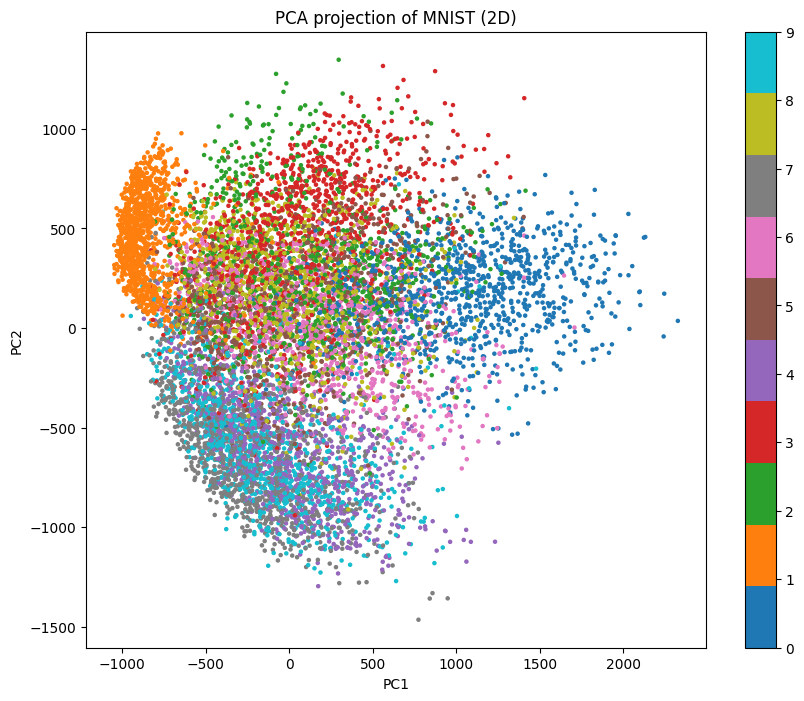

In [5]:
sample = 10000

plt.figure(figsize=(10,8))

scatter = plt.scatter(
    X_pca_2d[:sample,0],
    X_pca_2d[:sample,1],
    c=y[:sample].astype(int),
    cmap="tab10",
    s=5
)

plt.colorbar(scatter)

plt.title("PCA projection of MNIST (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

In [6]:
pca_3 = PCA(n_components=3)

X_pca_3d = pca_3.fit_transform(X)

print("Reduced shape:", X_pca_3d.shape)

Reduced shape: (70000, 3)


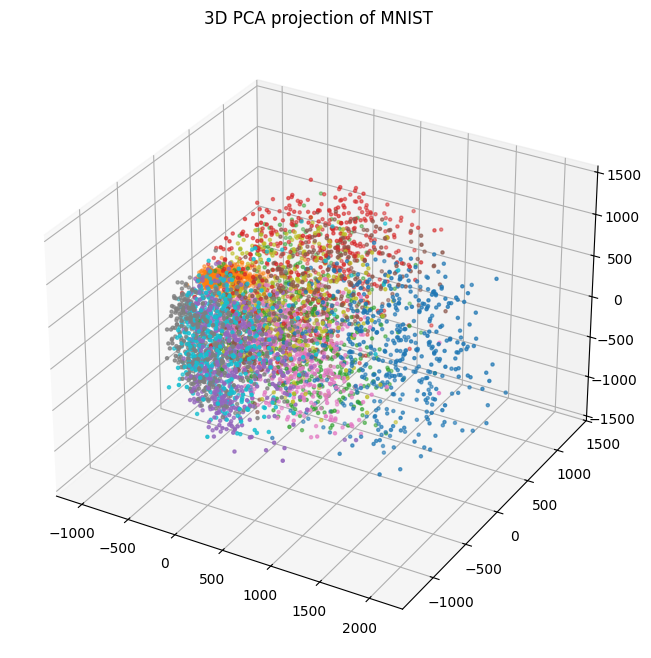

In [7]:
from mpl_toolkits.mplot3d import Axes3D

sample = 5000

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca_3d[:sample,0],
    X_pca_3d[:sample,1],
    X_pca_3d[:sample,2],
    c=y[:sample].astype(int),
    cmap="tab10",
    s=5
)

plt.title("3D PCA projection of MNIST")

plt.show()

In [8]:
print("Explained variance ratio (3 components):")

print(pca_3.explained_variance_ratio_)

print("Total explained variance:")

print(np.sum(pca_3.explained_variance_ratio_))

Explained variance ratio (3 components):
[0.09746116 0.07155445 0.06149531]
Total explained variance:
0.230510914900965


In [9]:
pca = PCA(n_components=3)

X_reduced = pca.fit_transform(X)

X_reconstructed = pca.inverse_transform(X_reduced)

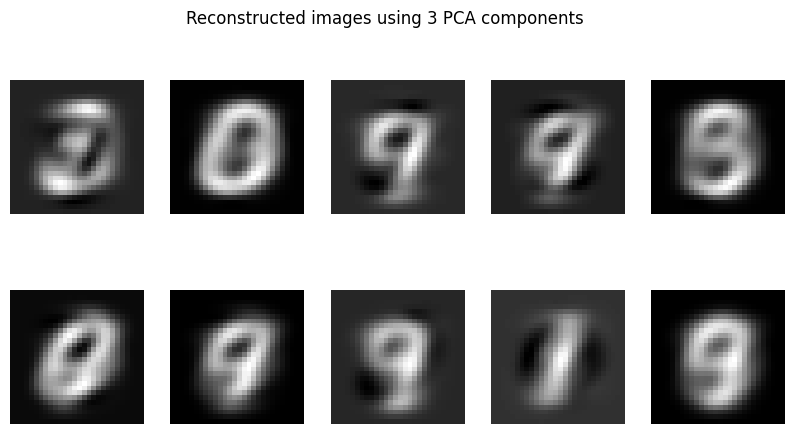

In [10]:
fig, axes = plt.subplots(2,5, figsize=(10,5))

for ax in axes.flat:

    idx = np.random.randint(0, X.shape[0])

    reconstructed = X_reconstructed[idx].reshape(28,28)

    ax.imshow(reconstructed, cmap='gray')

    ax.axis('off')

plt.suptitle("Reconstructed images using 3 PCA components")

plt.show()

In [11]:
mse = mean_squared_error(X, X_reconstructed)

print("Reconstruction MSE:", mse)

Reconstruction MSE: 3366.489667994886


In [12]:
components = [2,5,10,20,50,100]

mse_values = []
variance_values = []

for k in components:

    pca = PCA(n_components=k)

    X_reduced = pca.fit_transform(X)

    X_reconstructed = pca.inverse_transform(X_reduced)

    mse = mean_squared_error(X, X_reconstructed)

    mse_values.append(mse)

    variance_values.append(np.sum(pca.explained_variance_ratio_))

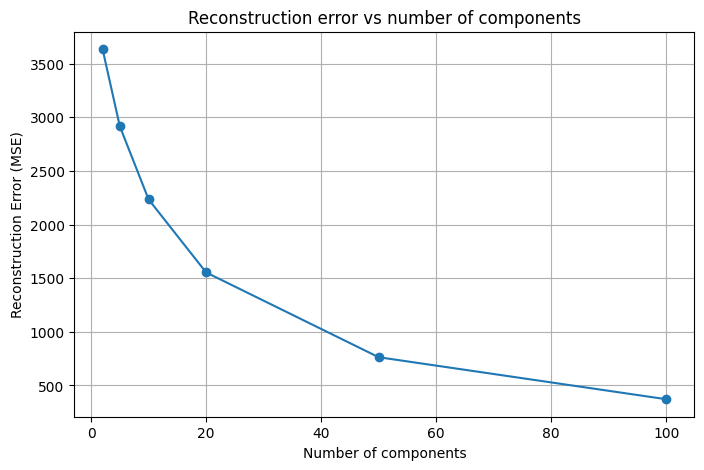

In [13]:
plt.figure(figsize=(8,5))

plt.plot(components, mse_values, marker='o')

plt.xlabel("Number of components")
plt.ylabel("Reconstruction Error (MSE)")

plt.title("Reconstruction error vs number of components")

plt.grid()

plt.show()

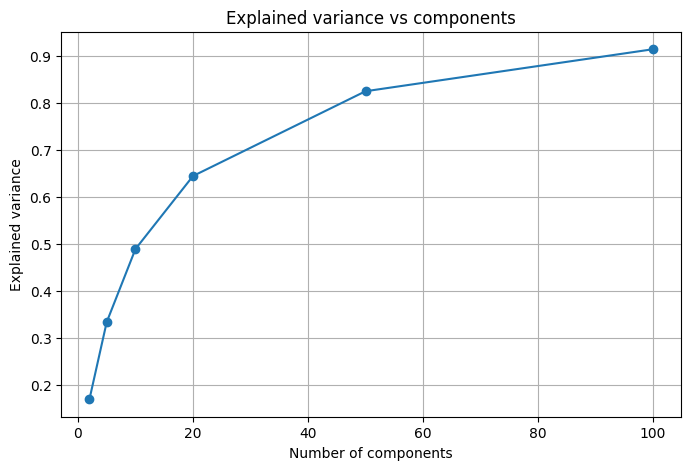

In [14]:
plt.figure(figsize=(8,5))

plt.plot(components, variance_values, marker='o')

plt.xlabel("Number of components")
plt.ylabel("Explained variance")

plt.title("Explained variance vs components")

plt.grid()

plt.show()